In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

In [2]:
# 1. Carga y Preparación del Dataset Transversal (oasis_cross-sectional.csv)
df = pd.read_csv('oasis_cross-sectional.csv')

# Selección de atributos clínicos y demográficos
features = ['Sex', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features].copy()

# Codificación de Sexo (M=0, F=1)
X['Sex'] = X['Sex'].map({'M': 0, 'F': 1})

# --- NUEVO LINEAMIENTO: Binarización de CDR (2 Clases) ---
# CDR 0 -> 0 (Non demented), CDR >= 0.5 -> 1 (Demented)
y = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)

# 2. Tratamiento de Datos Faltantes (Crítico en el set transversal)
# SES, Educ y MMSE tienen valores nulos en este dataset [3, 4]
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

FileNotFoundError: [Errno 2] No such file or directory: 'oasis_cross-sectional.csv'

Iniciando validaciones independientes...


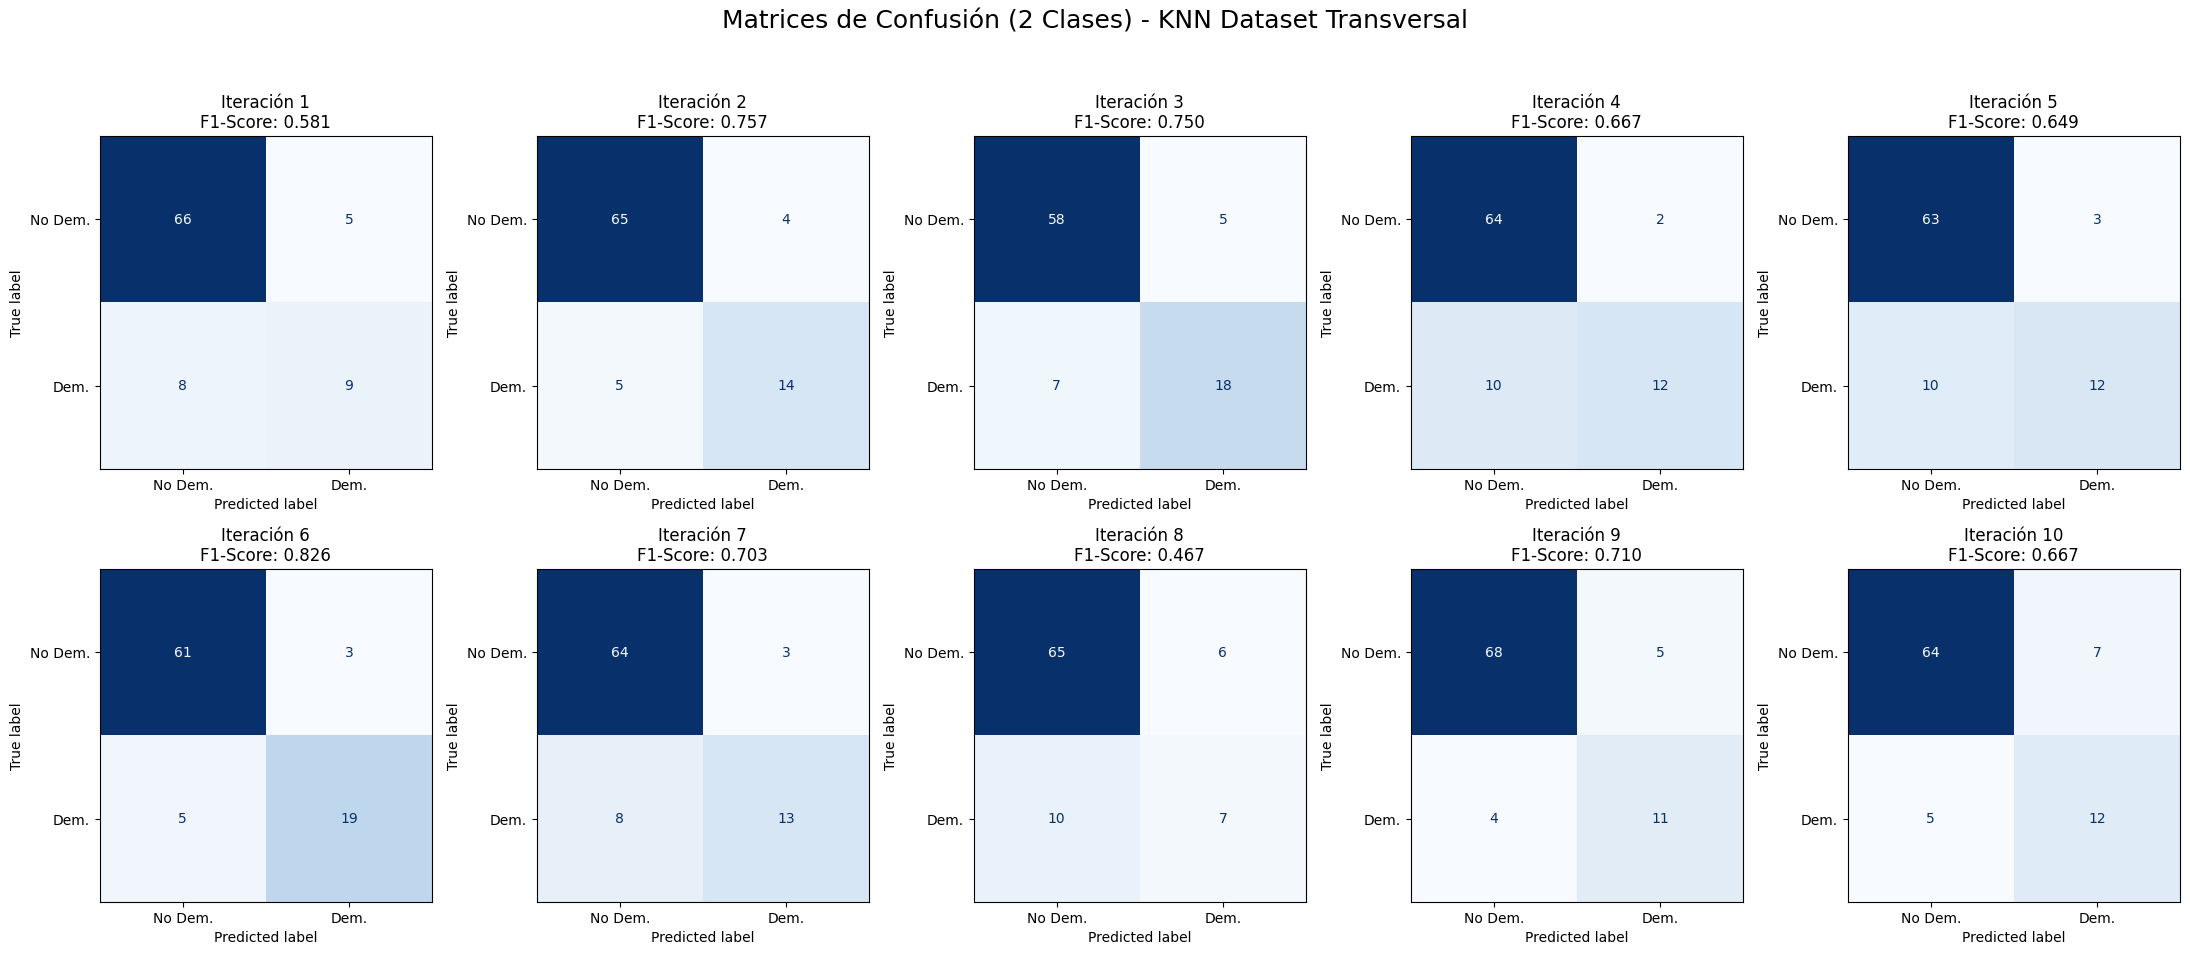


Métrica              | Promedio ± DE (10 iteraciones)
--------------------------------------------------
Accuracy             | 0.8693 ± 0.0255
Precision            | 0.7394 ± 0.1028
Recall               | 0.6339 ± 0.1158
F1-score             | 0.6775 ± 0.0950
AUC                  | 0.9041 ± 0.0383


In [ ]:
# 3. Configuración Experimental (10 Validaciones 80/20)
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Iniciando validaciones independientes...")

for i in range(10):
    # Partición aleatoria única por iteración (Sección 12 de la guía)
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=0.2, random_state=i
    )
    
    # 4. Escalamiento Z-score: Requisito de la guía para modelos espaciales [5, 6]
    # Se ajusta en entrenamiento y se aplica en prueba para evitar filtración
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 5. Entrenamiento del Modelo KNN (k=5 por defecto)
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_s, y_train)
    
    # Predicciones
    y_pred = knn.predict(X_test_s)
    y_proba = knn.predict_proba(X_test_s)[:, 1] # Probabilidades para AUC
    
    # 6. Cálculo de Métricas (Sección 13 de la guía)
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 7. Generación de la Matriz de Confusión para cada iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dem.', 'Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1-Score: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión (2 Clases) - KNN Dataset Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8. Reporte Final de Desempeño (Media ± DE)
print("\n" + "="*50)
print(f"{'Métrica':<20} | {'Promedio ± DE (10 iteraciones)':<20}")
print("-" * 50)
print(f"{'Accuracy':<20} | {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"{'Precision':<20} | {np.mean(results['prec']):.4f} ± {np.std(results['prec']):.4f}")
print(f"{'Recall':<20} | {np.mean(results['rec']):.4f} ± {np.std(results['rec']):.4f}")
print(f"{'F1-score':<20} | {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
print(f"{'AUC':<20} | {np.mean(results['auc']):.4f} ± {np.std(results['auc']):.4f}")
print("="*50)

Iniciando validaciones independientes...


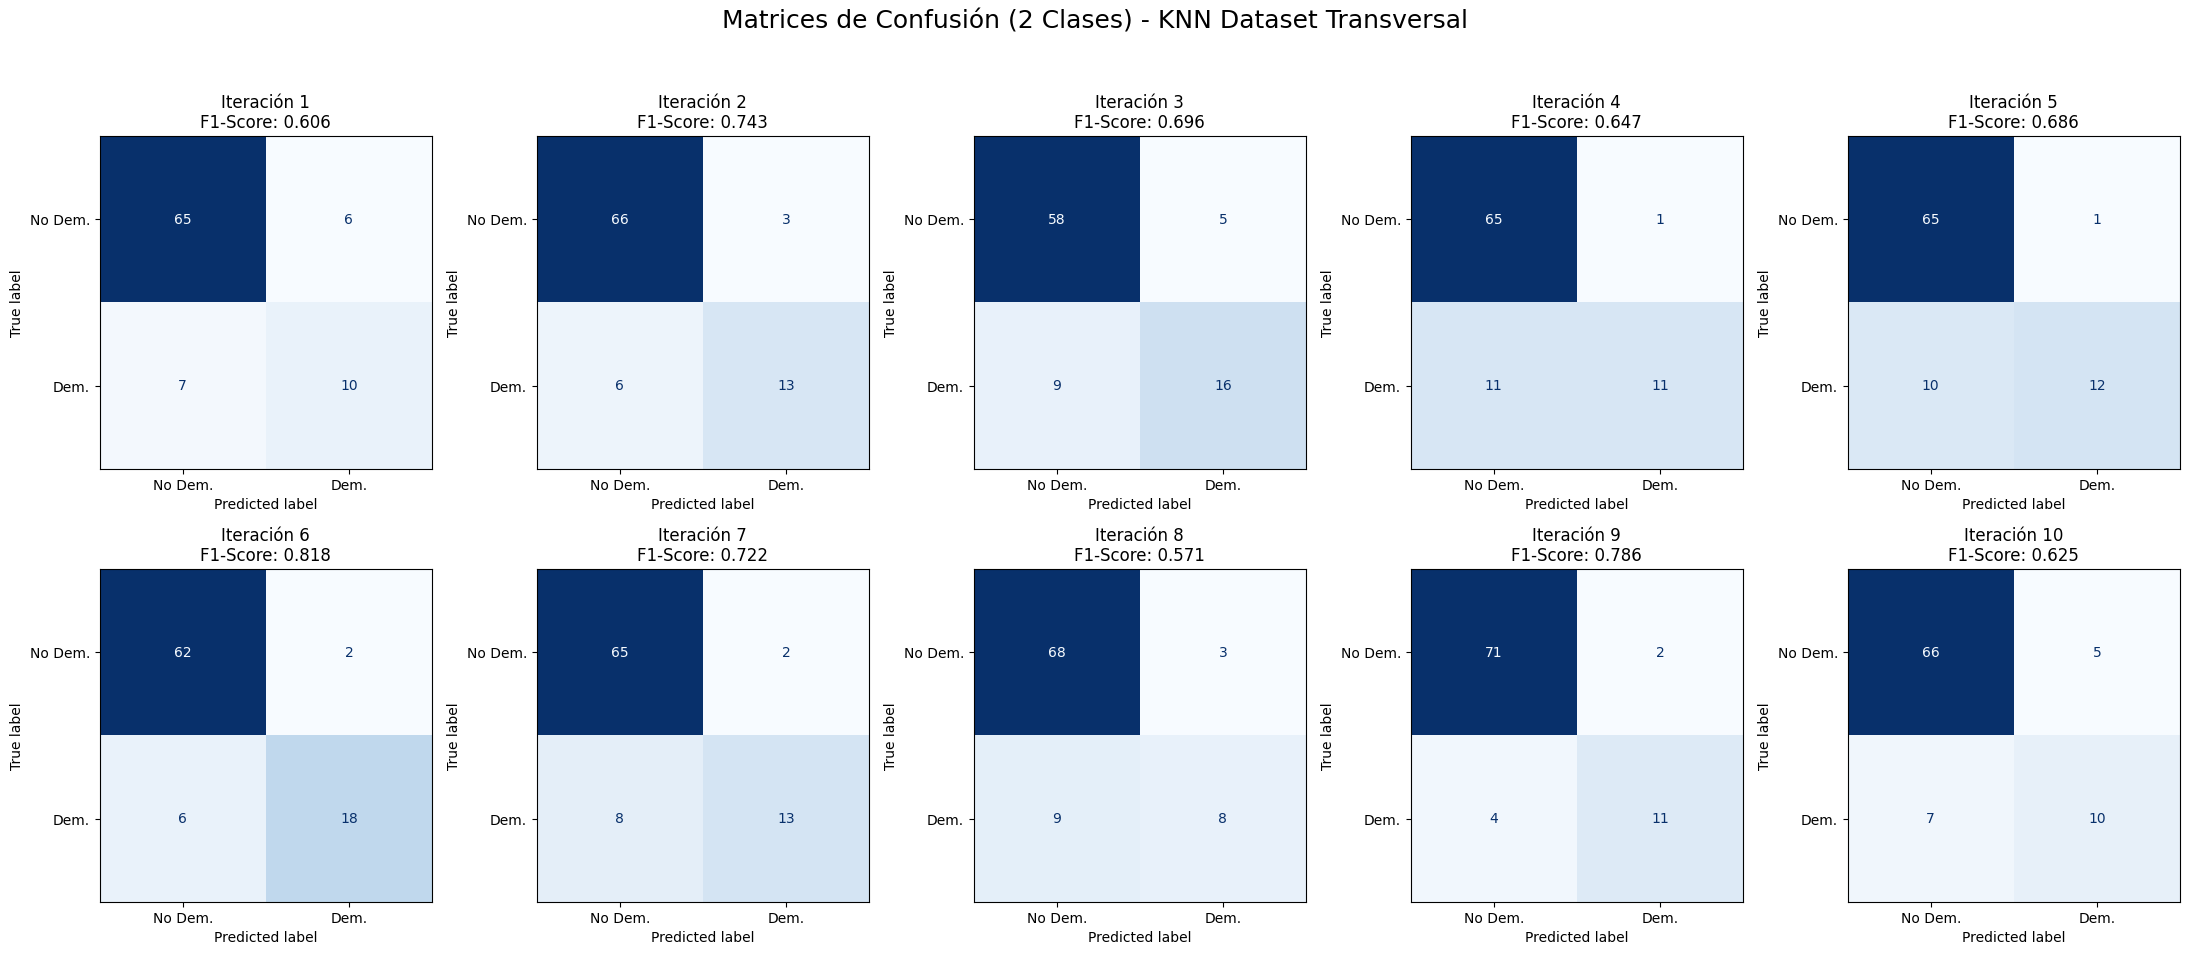


Métrica              | Promedio ± DE (10 iteraciones)
--------------------------------------------------
Accuracy             | 0.8784 ± 0.0264
Precision            | 0.8046 ± 0.1002
Recall               | 0.6119 ± 0.0883
F1-score             | 0.6900 ± 0.0753
AUC                  | 0.9393 ± 0.0189


In [ ]:
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Iniciando validaciones independientes...")

for i in range(10):
    # Partición aleatoria única por iteración (Sección 12 de la guía)
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=0.2, random_state=i
    )
    
    # 4. Escalamiento Z-score: Requisito de la guía para modelos espaciales [5, 6]
    # Se ajusta en entrenamiento y se aplica en prueba para evitar filtración
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 5. Entrenamiento del Modelo KNN (k=5 por defecto)
    knn = KNeighborsClassifier(n_neighbors=11)
    knn.fit(X_train_s, y_train)
    
    # Predicciones
    y_pred = knn.predict(X_test_s)
    y_proba = knn.predict_proba(X_test_s)[:, 1] # Probabilidades para AUC
    
    # 6. Cálculo de Métricas (Sección 13 de la guía)
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 7. Generación de la Matriz de Confusión para cada iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dem.', 'Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1-Score: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión (2 Clases) - KNN Dataset Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8. Reporte Final de Desempeño (Media ± DE)
print("\n" + "="*50)
print(f"{'Métrica':<20} | {'Promedio ± DE (10 iteraciones)':<20}")
print("-" * 50)
print(f"{'Accuracy':<20} | {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"{'Precision':<20} | {np.mean(results['prec']):.4f} ± {np.std(results['prec']):.4f}")
print(f"{'Recall':<20} | {np.mean(results['rec']):.4f} ± {np.std(results['rec']):.4f}")
print(f"{'F1-score':<20} | {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
print(f"{'AUC':<20} | {np.mean(results['auc']):.4f} ± {np.std(results['auc']):.4f}")

Buscando el k óptimo mediante 10 validaciones independientes por cada valor...


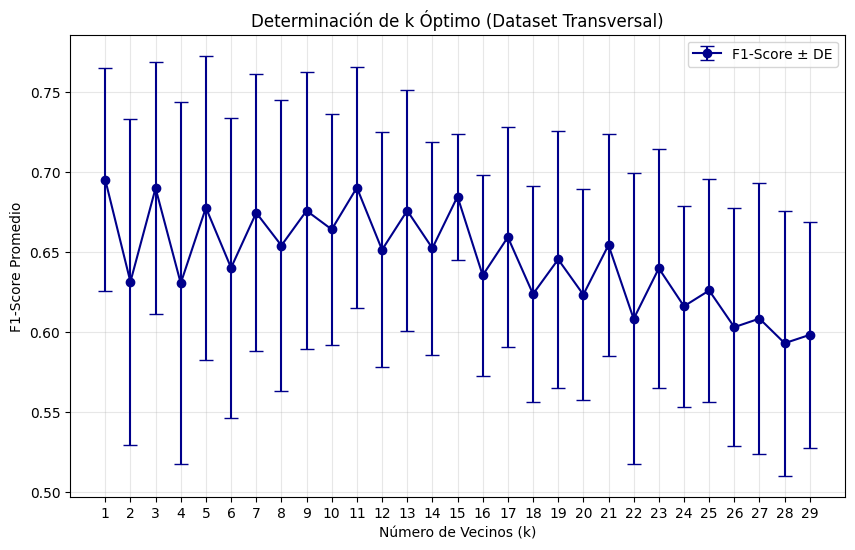

El valor de k con mejor desempeño promedio es: 1


In [ ]:
k_range = range(1, 30)
k_scores = []
k_stds = []

print("Buscando el k óptimo mediante 10 validaciones independientes por cada valor...")

for k in k_range:
    iter_f1 = []
    for i in range(10):
        # Partición 80/20 independiente [4]
        X_train, X_test, y_train, y_test = train_test_split(
            X_imputed, y, test_size=0.2, random_state=i
        )
        
        # Escalamiento Z-score obligatorio para KNN [6, 7]
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_s, y_train)
        preds = knn.predict(X_test_s)
        iter_f1.append(f1_score(y_test, preds))
    
    k_scores.append(np.mean(iter_f1))
    k_stds.append(np.std(iter_f1))

# 3. Visualización de la curva de desempeño [1]
plt.figure(figsize=(10, 6))
plt.errorbar(k_range, k_scores, yerr=k_stds, fmt='-o', color='darkblue', capsize=5, label='F1-Score ± DE')
plt.title("Determinación de k Óptimo (Dataset Transversal)")
plt.xlabel("Número de Vecinos (k)")
plt.ylabel("F1-Score Promedio")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

best_k = k_range[np.argmax(k_scores)]
print(f"El valor de k con mejor desempeño promedio es: {best_k}")